# Lab 4 — Modelado Estadístico

**Curso:** BE3006 · Análisis de Datos Biomédicos · UVG  
**Referencia:** Kubben et al. (2019), *Fundamentals of Clinical Data Science*, Cap. 8

---

## ¿De qué se trata este lab?

En Lab 3.1 generamos **108 pacientes sintéticos** con Synthea. Tenemos sus datos demográficos, diagnósticos, signos vitales, laboratorios, medicamentos y encuentros clínicos.

Ahora vamos a usar esos datos para responder **dos preguntas clínicas** con modelos estadísticos:

1. **¿Qué factores predicen los gastos de salud de un paciente?** → Regresión lineal
2. **¿Podemos predecir si un paciente tiene o desarrollará diabetes?** → Regresión logística

### Objetivos de aprendizaje

Al completar este lab podrás:

1. Transformar datos transaccionales (un registro por evento) en una **tabla analítica** (un registro por paciente)
2. Realizar **EDA clínico** orientado a modelado predictivo
3. Formular y probar **hipótesis estadísticas** con significado clínico
4. Construir modelos de **regresión lineal y logística**, interpretando sus coeficientes
5. Evaluar modelos con **métricas apropiadas** (R², ROC/AUC, sensibilidad, especificidad)
6. Aplicar **validación cruzada** y detectar **fuga de datos** (data leakage)

---

### Estructura del lab

| Parte | Tema | Tipo |
|-------|------|------|
| 0 | Setup y carga de datos | Guiado |
| 1 | Ingeniería de características | Guiado + ejercicios |
| 2 | EDA clínico | Guiado + ejercicios |
| 3 | Pruebas de hipótesis | Guiado + ejercicios |
| 4 | Regresión lineal | Guiado + ejercicios |
| 5 | Regresión logística | Guiado + ejercicios |
| 6 | Validación y fuga de datos | Ejercicios |
| 7 | Reflexión final | Preguntas abiertas |

---
## Parte 0: Setup y Carga de Datos

Primero importamos las librerías que necesitaremos. Hay tres grupos principales:

- **Datos y visualización:** `pandas`, `numpy`, `matplotlib`, `seaborn` — ya los conoces de Lab 3.1
- **Estadística:** `scipy.stats` — contiene pruebas estadísticas (t-test, chi-cuadrado, etc.)
- **Machine learning:** `scikit-learn` — contiene modelos (regresión), métricas (ROC, AUC) y herramientas de validación

In [1]:
# ── Datos y visualización ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date
import warnings
warnings.filterwarnings('ignore')

# ── Estadística ──
from scipy import stats

# ── Machine Learning (scikit-learn) ──
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline

# ── Configuración de gráficos ──
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Carga de datos

Cargamos los mismos 5 archivos CSV de Synthea que usamos en Lab 3.1. Recuerda que cada archivo representa un tipo diferente de dato clínico:

| Archivo | Contenido | Registros |
|---------|-----------|-----------|
| `patients.csv` | Demografía (edad, género, ingresos, gastos) | ~109 |
| `conditions.csv` | Diagnósticos codificados en SNOMED-CT | ~3,444 |
| `encounters.csv` | Visitas/encuentros clínicos | ~5,758 |
| `medications.csv` | Medicamentos prescritos (RxNorm) | ~4,184 |
| `observations.csv` | Signos vitales y laboratorios (LOINC) | ~70,743 |

In [2]:
DATA = Path("../data")

patients     = pd.read_csv(DATA / "patients.csv")
conditions   = pd.read_csv(DATA / "conditions.csv")
encounters   = pd.read_csv(DATA / "encounters.csv")
medications  = pd.read_csv(DATA / "medications.csv")
observations = pd.read_csv(DATA / "observations.csv")

print(f"patients:     {patients.shape}")
print(f"conditions:   {conditions.shape}")
print(f"encounters:   {encounters.shape}")
print(f"medications:  {medications.shape}")
print(f"observations: {observations.shape}")

patients:     (108, 28)
conditions:   (3443, 7)
encounters:   (5757, 15)
medications:  (4183, 13)
observations: (70742, 9)


---
## Parte 1: Ingeniería de Características

### ¿Qué es y por qué la necesitamos?

Los datos de Synthea están en formato **transaccional**: un registro por cada evento clínico. Por ejemplo, `observations.csv` tiene ~70,000 filas porque cada vez que se midió la presión arterial o se tomó un laboratorio, se creó una fila.

Pero para modelar necesitamos formato **analítico**: **una fila por paciente**, donde cada columna sea una variable (feature) que describa a ese paciente.

```
ANTES (transaccional):                    DESPUÉS (analítico):
┌──────────┬───────────┬───────┐          ┌──────────┬─────┬─────┬──────┐
│ PATIENT  │ DESC      │ VALUE │          │ PATIENT  │ age │ bmi │ sbp  │
├──────────┼───────────┼───────┤          ├──────────┼─────┼─────┼──────┤
│ ABC123   │ BMI       │ 28.5  │          │ ABC123   │ 45  │28.5 │ 130  │
│ ABC123   │ BMI       │ 29.1  │   ──▶    │ DEF456   │ 62  │25.1 │ 145  │
│ ABC123   │ Sys BP    │ 130   │          └──────────┴─────┴─────┴──────┘
│ DEF456   │ BMI       │ 25.1  │
│ DEF456   │ Sys BP    │ 145   │
└──────────┴───────────┴───────┘
```

Este proceso de transformación se llama **ingeniería de características** (feature engineering) y es el paso más importante (y donde más errores se cometen) en cualquier proyecto de modelado.

### 1.1 Demografía (desde `patients.csv`)

Empezamos con lo más simple: datos que ya están a nivel de paciente.

- **Edad**: la calculamos restando la fecha de nacimiento (`BIRTHDATE`) de la fecha de referencia
- **Género**: convertimos `M`/`F` a numérico (1/0) para que el modelo lo pueda usar
- **Ingresos y gastos**: ya son numéricos, los tomamos directamente

In [3]:
# Empezamos construyendo df_model con una fila por paciente
df_model = patients[['Id']].copy()

# ── Edad ──
# Convertimos BIRTHDATE a fecha y calculamos la edad en años
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
ref_date = pd.Timestamp('2020-01-01')  # Fecha de referencia (datos generados hasta ~2020)
df_model['age'] = ((ref_date - patients['BIRTHDATE']).dt.days / 365.25).astype(int)

# ── Género ──
# Convertimos a binario: M=1, F=0 (es arbitrario, solo necesitamos números)
df_model['is_male'] = (patients['GENDER'] == 'M').astype(int)

# ── Ingresos y gastos de salud ──
df_model['income'] = patients['INCOME']
df_model['healthcare_expenses'] = patients['HEALTHCARE_EXPENSES']

print(f"Pacientes: {len(df_model)}")
df_model.head()

Pacientes: 108


,Id,age,is_male,income,healthcare_expenses
0,4f083ce3-f12b-bb4b-7353-e17f0cd55b0a,21,1,141031,67187.24
1,aee7bbe1-0c45-c028-1e62-1f4cdb30c273,9,1,102779,52600.02
2,46ee9d82-b52c-856d-069b-5064ff052225,24,0,124612,113101.08
3,5e688e99-61b3-5c88-3f60-21df8aaced27,10,1,22038,2450.05
4,46976cf7-b0bf-be20-39a5-9f425a52886d,12,0,95959,46052.75


### 1.2 Variable objetivo: ¿tiene diabetes?

Para el modelo de regresión logística necesitamos una variable **binaria** (sí/no). Vamos a crear `has_diabetes` buscando en `conditions.csv` si el paciente tiene algún diagnóstico de diabetes o prediabetes.

Recordemos de Lab 2 que los diagnósticos en Synthea están codificados con **SNOMED-CT**. Buscamos por descripción para simplificar:

In [4]:
# Buscamos pacientes con cualquier condición que contenga "diabetes" o "Prediabetes"
# str.contains() busca un patrón en el texto, case=False ignora mayúsculas/minúsculas
diabetes_patients = conditions[
    conditions['DESCRIPTION'].str.contains('iabetes|rediabetes', case=False, na=False)
]['PATIENT'].unique()

# Creamos la columna binaria: 1 si el paciente está en la lista, 0 si no
df_model['has_diabetes'] = df_model['Id'].isin(diabetes_patients).astype(int)

# También creamos has_hypertension para usarla después como feature
hypertension_patients = conditions[
    conditions['DESCRIPTION'].str.contains('hypertension', case=False, na=False)
]['PATIENT'].unique()
df_model['has_hypertension'] = df_model['Id'].isin(hypertension_patients).astype(int)

# Veamos la prevalencia
print("=== Prevalencia en nuestra población ===")
print(f"Diabetes/prediabetes: {df_model['has_diabetes'].sum()} de {len(df_model)} "
      f"({df_model['has_diabetes'].mean():.1%})")
print(f"Hipertensión:         {df_model['has_hypertension'].sum()} de {len(df_model)} "
      f"({df_model['has_hypertension'].mean():.1%})")

=== Prevalencia en nuestra población ===
Diabetes/prediabetes: 37 de 108 (34.3%)
Hipertensión:         17 de 108 (15.7%)


### 1.3 Signos vitales (desde `observations.csv`)

Ahora viene la parte interesante: extraer signos vitales del archivo de observaciones. Cada paciente tiene **múltiples mediciones** a lo largo del tiempo. Nuestra estrategia: tomar la **medición más reciente** de cada signo vital.

**Ejemplo guiado: extraer el último BMI de cada paciente**

El proceso es:
1. Filtrar `observations` para quedarnos solo con filas de BMI
2. Ordenar por fecha descendente (más reciente primero)
3. Quedarnos con la primera fila de cada paciente (`drop_duplicates`)
4. El resultado es un valor por paciente

In [5]:
def extract_latest_observation(observations_df, description, col_name):
    """
    Extrae la medición más reciente de una observación para cada paciente.
    
    Parámetros:
    - observations_df: DataFrame de observations.csv
    - description: texto exacto de la observación (ej: "Body mass index (BMI) [Ratio]")
    - col_name: nombre que tendrá la columna en nuestro df_model
    
    Retorna: DataFrame con columnas [PATIENT, col_name]
    """
    filtered = observations_df[
        observations_df['DESCRIPTION'] == description
    ].copy()
    
    # Ordenamos por fecha descendente para que la más reciente quede primero
    filtered = filtered.sort_values('DATE', ascending=False)
    
    # drop_duplicates con keep='first' se queda con la primera fila de cada paciente
    # (que es la más reciente porque ya ordenamos)
    latest = filtered.drop_duplicates(subset='PATIENT', keep='first')
    
    # Convertimos VALUE a numérico (por si hay valores no numéricos)
    latest[col_name] = pd.to_numeric(latest['VALUE'], errors='coerce')
    
    return latest[['PATIENT', col_name]]


def merge_feature(df, feature_df, col_name):
    """
    Une una feature al df_model de forma segura.
    Si la columna ya existe (por re-ejecutar la celda), la reemplaza en vez de duplicarla.
    Esto evita el problema de columnas _x, _y al re-ejecutar celdas.
    """
    if col_name in df.columns:
        df = df.drop(columns=[col_name])
    df = df.merge(feature_df, left_on='Id', right_on='PATIENT', how='left').drop(columns='PATIENT')
    return df


# ── Ejemplo: extraer BMI ──
bmi = extract_latest_observation(observations, "Body mass index (BMI) [Ratio]", "bmi")
print(f"BMI extraído para {len(bmi)} pacientes")
print(f"BMI promedio: {bmi['bmi'].mean():.1f} kg/m²")

# Unimos al df_model usando merge_feature (seguro para re-ejecutar)
df_model = merge_feature(df_model, bmi, "bmi")

BMI extraído para 105 pacientes
BMI promedio: 25.6 kg/m²


**Ejercicio 1.3:** Usando la función  que acabamos de definir, extrae las siguientes observaciones y únelas a :

| Descripción en observations.csv | Nombre de columna |
|---|---|
|  |  |
|  |  |
|  |  |

**Pista:** Sigue el mismo patrón del ejemplo de BMI arriba. Para cada observación: (1) llama a , (2) usa .

In [6]:
# ── EJERCICIO 1.3: Extrae signos vitales ──
# Completa el código para extraer systolic_bp, diastolic_bp y heart_rate

# Presión sistólica
sbp = extract_latest_observation(observations, "Systolic Blood Pressure", "systolic_bp")
df_model = merge_feature(df_model, sbp, "systolic_bp")

# Presión diastólica
dbp = extract_latest_observation(observations, "Diastolic Blood Pressure", "diastolic_bp")
df_model = merge_feature(df_model, dbp, "diastolic_bp")

# Frecuencia cardíaca
hr = extract_latest_observation(observations, "Heart rate", "heart_rate")
df_model = merge_feature(df_model, hr, "heart_rate")

print(f"Columnas actuales: {list(df_model.columns)}")
df_model[['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate']].describe()

Columnas actuales: ['Id', 'age', 'is_male', 'income', 'healthcare_expenses', 'has_diabetes', 'has_hypertension', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate']


,age,bmi,systolic_bp,diastolic_bp,heart_rate
count,108.000000,105.000000,108.000000,108.000000,108.000000
mean,31.111111,25.627619,117.044444,79.963889,79.555556
std,22.958855,4.872302,14.499251,9.641358,11.780178
min,-5.000000,14.900000,75.000000,51.000000,61.000000
25%,10.750000,22.300000,108.500000,74.000000,70.000000
50%,29.500000,27.400000,117.000000,80.500000,80.000000
75%,50.500000,28.700000,128.000000,86.250000,87.000000
max,94.000000,42.800000,147.000000,111.000000,100.000000


### 1.4 Laboratorios

Ahora extraemos laboratorios clave. Estos son importantes porque varios están directamente relacionados con el riesgo de diabetes y enfermedad cardiovascular.

**Ejercicio 1.4:** Extrae los siguientes laboratorios usando `extract_latest_observation` y únelos a `df_model`:

| Descripción en observations.csv | Columna | ¿Qué mide? |
|---|---|---|
| `"Hemoglobin A1c/Hemoglobin.total in Blood"` | `hba1c` | Control de glucosa a largo plazo |
| `"Glucose [Mass/volume] in Blood"` | `glucose` | Azúcar en sangre |
| `"Cholesterol [Mass/volume] in Serum or Plasma"` | `cholesterol_total` | Colesterol total |
| `"Cholesterol in HDL [Mass/volume] in Serum or Plasma"` | `hdl` | Colesterol "bueno" |
| `"Triglyceride [Mass/volume] in Serum or Plasma"` | `triglycerides` | Triglicéridos |

In [8]:
# ── EJERCICIO 1.4: Extrae laboratorios ──
# Sigue el mismo patrón: extract_latest_observation() + merge_feature()

labs_to_extract = [
    ("Hemoglobin A1c/Hemoglobin.total in Blood", "hba1c"),
    ("Glucose [Mass/volume] in Blood", "glucose"),
    ("Cholesterol [Mass/volume] in Serum or Plasma", "cholesterol_total"),
    ("Cholesterol in HDL [Mass/volume] in Serum or Plasma", "hdl"),
    ("Triglyceride [Mass/volume] in Serum or Plasma", "triglycerides"),
]

for description, col_name in labs_to_extract:
    # TU CÓDIGO AQUÍ: extrae la observación y haz merge_feature con df_model
    lab = extract_latest_observation(observations, description, col_name)
    df_model = merge_feature(df_model, lab, col_name)

df_model.head()

,Id,age,is_male,income,healthcare_expenses,has_diabetes,has_hypertension,bmi,systolic_bp,diastolic_bp,heart_rate,hba1c,glucose,cholesterol_total,hdl,triglycerides
0,4f083ce3-f12b-bb4b-7353-e17f0cd55b0a,21,1,141031,67187.24,1,0,26.4,137.0,88.0,63.0,6.2,82.8,NaN,NaN,NaN
1,aee7bbe1-0c45-c028-1e62-1f4cdb30c273,9,1,102779,52600.02,0,0,16.6,117.0,93.0,96.0,NaN,NaN,NaN,NaN,NaN
2,46ee9d82-b52c-856d-069b-5064ff052225,24,0,124612,113101.08,1,0,26.0,132.0,90.0,93.0,5.8,67.1,NaN,NaN,NaN
3,5e688e99-61b3-5c88-3f60-21df8aaced27,10,1,22038,2450.05,0,0,20.9,146.0,91.0,69.0,NaN,NaN,NaN,NaN,NaN
4,46976cf7-b0bf-be20-39a5-9f425a52886d,12,0,95959,46052.75,0,0,27.3,117.0,95.0,99.0,NaN,NaN,NaN,NaN,NaN


### 1.5 Conteos de utilización

Otra fuente importante de features son los **conteos**: cuántos encuentros tuvo un paciente, cuántos medicamentos toma, cuántas condiciones tiene. Estos capturan la "complejidad" del paciente.

**Ejercicio 1.5:** Calcula los siguientes conteos por paciente y únelos a `df_model`:

| Conteo | Columna | Fuente |
|---|---|---|
| Total de encuentros | `n_encounters` | `encounters.csv`, contar filas por PATIENT |
| Encuentros de emergencia | `n_emergency` | `encounters.csv`, filtrar ENCOUNTERCLASS == "emergency" |
| Medicamentos distintos | `n_medications` | `medications.csv`, contar DESCRIPTION únicos por PATIENT |
| Condiciones distintas | `n_conditions` | `conditions.csv`, contar DESCRIPTION únicos por PATIENT |

**Pista:** Usa `.groupby('PATIENT').size()` para contar filas, o `.groupby('PATIENT')['DESCRIPTION'].nunique()` para contar valores únicos.

In [9]:
# ── EJERCICIO 1.5: Conteos de utilización ──

# Ejemplo: total de encuentros por paciente
n_enc = encounters.groupby('PATIENT').size().reset_index(name='n_encounters')
df_model = merge_feature(df_model, n_enc, 'n_encounters')

# Encuentros de emergencia
n_emg = (
    encounters[encounters['ENCOUNTERCLASS'] == 'emergency']
    .groupby('PATIENT')
    .size()
    .reset_index(name='n_emergency')
)
df_model = merge_feature(df_model, n_emg, 'n_emergency')

# Medicamentos distintos
n_meds = (
    medications.groupby('PATIENT')['DESCRIPTION']
    .nunique()
    .reset_index(name='n_medications')
)
df_model = merge_feature(df_model, n_meds, 'n_medications')

# Condiciones distintas
n_cond = (
    conditions.groupby('PATIENT')['DESCRIPTION']
    .nunique()
    .reset_index(name='n_conditions')
)
df_model = merge_feature(df_model, n_cond, 'n_conditions')

# Rellenamos NaN con 0 para los conteos (si un paciente no tiene emergencias, es 0, no NaN)
for col in ['n_encounters', 'n_emergency', 'n_medications', 'n_conditions']:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0).astype(int)

print(f"Forma final de df_model: {df_model.shape}")
df_model.head()

Forma final de df_model: (108, 20)


,Id,age,is_male,income,healthcare_expenses,has_diabetes,has_hypertension,bmi,systolic_bp,diastolic_bp,heart_rate,hba1c,glucose,cholesterol_total,hdl,triglycerides,n_encounters,n_emergency,n_medications,n_conditions
0,4f083ce3-f12b-bb4b-7353-e17f0cd55b0a,21,1,141031,67187.24,1,0,26.4,137.0,88.0,63.0,6.2,82.8,NaN,NaN,NaN,10,1,3,11
1,aee7bbe1-0c45-c028-1e62-1f4cdb30c273,9,1,102779,52600.02,0,0,16.6,117.0,93.0,96.0,NaN,NaN,NaN,NaN,NaN,31,2,5,13
2,46ee9d82-b52c-856d-069b-5064ff052225,24,0,124612,113101.08,1,0,26.0,132.0,90.0,93.0,5.8,67.1,NaN,NaN,NaN,26,0,7,23
3,5e688e99-61b3-5c88-3f60-21df8aaced27,10,1,22038,2450.05,0,0,20.9,146.0,91.0,69.0,NaN,NaN,NaN,NaN,NaN,18,1,3,5
4,46976cf7-b0bf-be20-39a5-9f425a52886d,12,0,95959,46052.75,0,0,27.3,117.0,95.0,99.0,NaN,NaN,NaN,NaN,NaN,20,0,5,10


### 1.6 Manejo de valores faltantes

Antes de modelar, necesitamos lidiar con los **valores faltantes (NaN)**. Algunos pacientes no tienen ciertos laboratorios porque nunca se los ordenaron.

Hay varias estrategias para manejar NaN:
- **Eliminar filas** con NaN — perdemos pacientes (malo con solo 108)
- **Imputar con la mediana** — reemplazamos NaN con el valor central de la columna
- **Imputar con modelos** — más sofisticado pero innecesario aquí

Usaremos la **mediana** porque es robusta a valores extremos (outliers). Pero es importante saber que esto introduce un supuesto: los pacientes sin laboratorio se comportan como el paciente "promedio", lo cual no siempre es cierto.

In [10]:
# Veamos cuántos valores faltantes tiene cada columna
print("=== Valores faltantes por columna ===")
missing = df_model.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing.to_string())
else:
    print("No hay valores faltantes.")

# Imputamos con la mediana las columnas numéricas (excepto Id y has_diabetes)
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_model[col].isnull().any():
        median_val = df_model[col].median()
        n_missing = df_model[col].isnull().sum()
        df_model[col] = df_model[col].fillna(median_val)
        print(f"  {col}: {n_missing} NaN imputados con mediana = {median_val:.1f}")

print(f"\nTabla analitica final: {df_model.shape[0]} pacientes x {df_model.shape[1]} columnas")
print(f"Valores faltantes restantes: {df_model.isnull().sum().sum()}")

=== Valores faltantes por columna ===
bmi                   3
hba1c                67
glucose              66
cholesterol_total    50
hdl                  50
triglycerides        50
  bmi: 3 NaN imputados con mediana = 27.4
  hba1c: 67 NaN imputados con mediana = 6.0
  glucose: 66 NaN imputados con mediana = 79.2
  cholesterol_total: 50 NaN imputados con mediana = 185.3
  hdl: 50 NaN imputados con mediana = 54.1
  triglycerides: 50 NaN imputados con mediana = 131.6

Tabla analitica final: 108 pacientes x 20 columnas
Valores faltantes restantes: 0


**CHECKPOINT 1** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 1: feature engineering complete"
```

---

## Parte 2: Análisis Exploratorio de Datos (EDA)

Antes de modelar, **debemos entender nuestros datos**. El EDA no es un paso opcional — es donde descubrimos problemas, generamos hipótesis y desarrollamos intuición clínica.

### 2.1 Resumen estadístico

Empezamos con `.describe()` para ver la distribución general de cada variable numérica. Fíjate en:
- **mean vs median (50%)**: si son muy diferentes, la distribución es asimétrica
- **min y max**: ¿hay valores extremos que no tienen sentido clínico?
- **std**: ¿qué tan dispersos son los datos?

In [11]:
# Excluimos la columna Id (es un identificador, no una variable numérica)
df_model.drop(columns='Id', errors='ignore').describe().round(1)

,age,is_male,income,healthcare_expenses,has_diabetes,has_hypertension,bmi,systolic_bp,diastolic_bp,heart_rate,hba1c,glucose,cholesterol_total,hdl,triglycerides,n_encounters,n_emergency,n_medications,n_conditions
count,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0
mean,31.1,0.5,124982.1,114040.0,0.3,0.2,25.7,117.0,80.0,79.6,5.9,80.8,187.9,53.5,135.2,53.3,2.3,6.4,17.6
std,23.0,0.5,196872.1,157894.6,0.5,0.4,4.8,14.5,9.6,11.8,0.7,11.0,33.2,7.2,33.4,64.1,5.6,4.3,9.6
min,-5.0,0.0,2130.0,100.0,0.0,0.0,14.9,75.0,51.0,61.0,2.6,64.2,96.4,28.2,101.8,3.0,0.0,0.0,1.0
25%,10.8,0.0,26879.2,20294.4,0.0,0.0,22.4,108.5,74.0,70.0,6.0,79.2,181.8,53.7,131.2,22.8,0.0,3.0,10.8
50%,29.5,0.0,59437.0,58915.1,0.0,0.0,27.4,117.0,80.5,80.0,6.0,79.2,185.4,54.1,131.6,36.0,1.0,5.0,17.5
75%,50.5,1.0,137680.0,149247.1,1.0,0.0,28.6,128.0,86.2,87.0,6.0,79.2,187.8,54.5,132.8,57.2,2.0,9.0,23.0
max,94.0,1.0,905454.0,886960.9,1.0,1.0,42.8,147.0,111.0,100.0,7.4,169.8,307.1,78.3,441.8,475.0,45.0,20.0,48.0


### 2.2 Distribuciones univariadas

Los histogramas nos muestran la **forma** de cada distribución. Esto es importante porque:
- Algunas pruebas estadísticas asumen distribución normal (simétrica, forma de campana)
- Variables muy asimétricas pueden necesitar transformación
- Outliers extremos pueden distorsionar el modelo

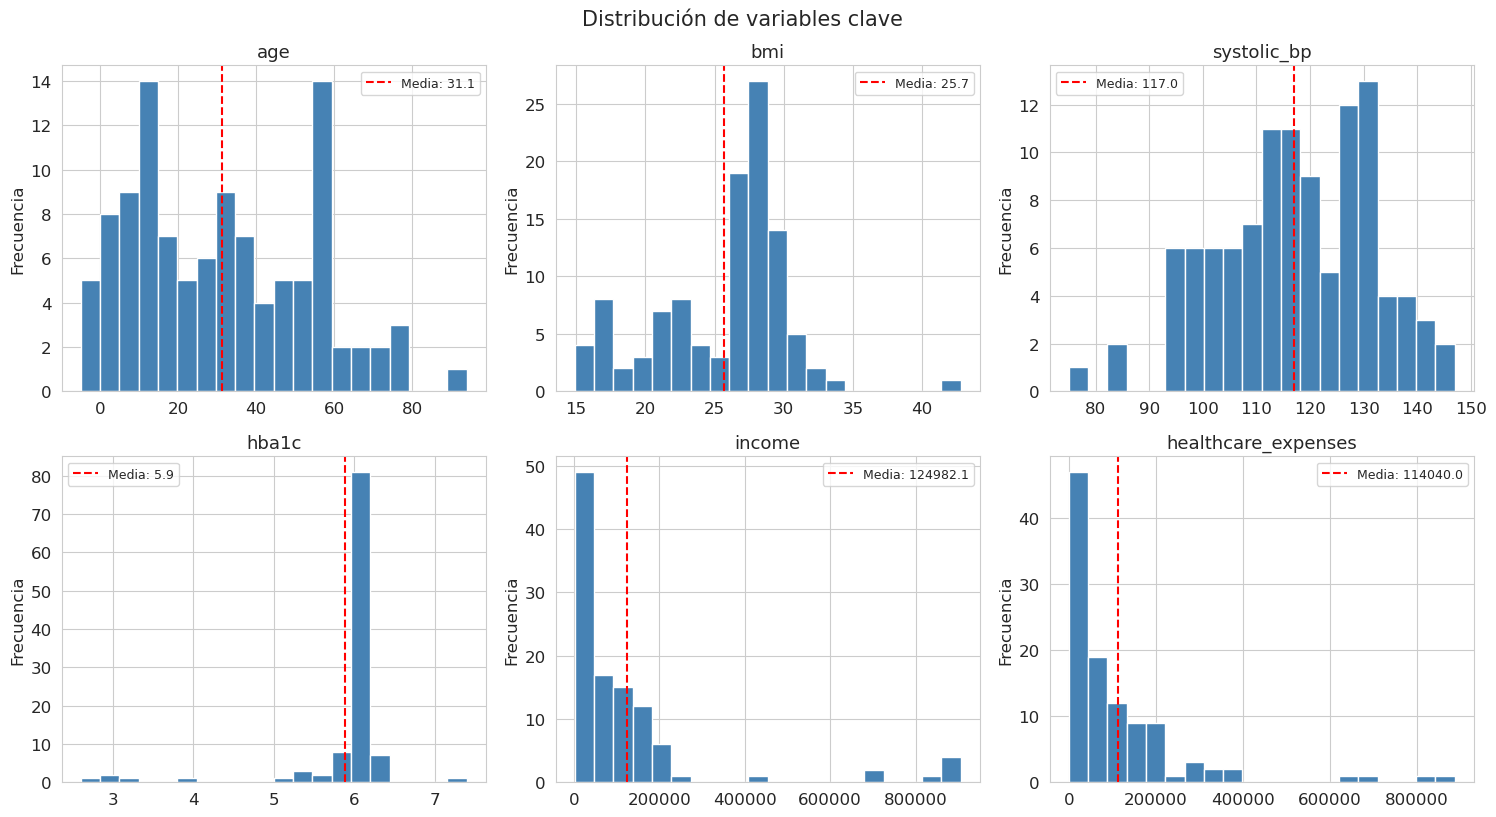

In [12]:
# Seleccionamos variables clave para visualizar
plot_vars = ['age', 'bmi', 'systolic_bp', 'hba1c', 'income', 'healthcare_expenses']
# Filtramos solo las que existen en df_model (por si no completaste algún ejercicio)
plot_vars = [v for v in plot_vars if v in df_model.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    axes[i].hist(df_model[var].dropna(), bins=20, edgecolor='white', color='steelblue')
    axes[i].set_title(var, fontsize=13)
    axes[i].set_ylabel('Frecuencia')
    # Línea vertical en la media
    mean_val = df_model[var].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

# Ocultamos ejes vacíos si hay menos de 6 variables
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Distribución de variables clave", y=1.02, fontsize=15)
plt.show()

### 2.3 Distribución de la variable objetivo

Para regresión logística necesitamos saber qué tan **balanceadas** están las clases. Si una clase domina (ej: 95% negativos, 5% positivos), el modelo puede simplemente predecir siempre "negativo" y tener accuracy alta pero ser inútil.

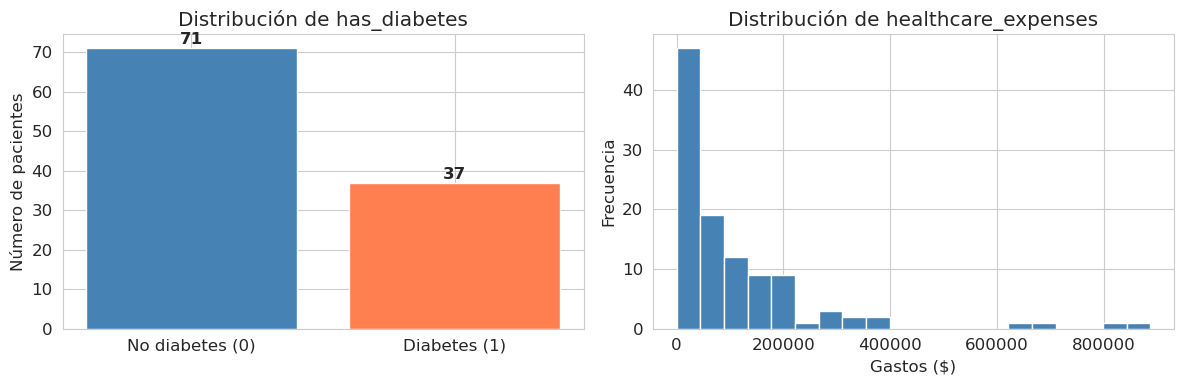

Prevalencia de diabetes/prediabetes: 34.3%
Esto significa que ~34% de los pacientes son positivos y ~66% negativos.
Con esta prevalencia tenemos suficiente representación de ambas clases para un modelo didáctico.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo de diabetes
counts = df_model['has_diabetes'].value_counts()
axes[0].bar(['No diabetes (0)', 'Diabetes (1)'], counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Distribución de has_diabetes')
axes[0].set_ylabel('Número de pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Histograma de gastos de salud (variable objetivo para regresión lineal)
axes[1].hist(df_model['healthcare_expenses'], bins=20, edgecolor='white', color='steelblue')
axes[1].set_title('Distribución de healthcare_expenses')
axes[1].set_xlabel('Gastos ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

prev = df_model['has_diabetes'].mean()
print(f"Prevalencia de diabetes/prediabetes: {prev:.1%}")
print(f"Esto significa que ~{prev:.0%} de los pacientes son positivos y ~{1-prev:.0%} negativos.")
print("Con esta prevalencia tenemos suficiente representación de ambas clases para un modelo didáctico.")

### 2.4 Comparaciones por grupo (boxplots)

Los **boxplots** son excelentes para comparar distribuciones entre dos grupos. Aquí comparamos pacientes **con** y **sin** diabetes para ver qué variables podrían ser predictores útiles.

El boxplot muestra:
- La **caja**: contiene el 50% central de los datos (del percentil 25 al 75)
- La **línea dentro de la caja**: la mediana (percentil 50)
- Los **bigotes**: se extienden hasta 1.5 veces el rango intercuartílico
- Los **puntos fuera**: valores atípicos (outliers)

In [ ]:
# Ejemplo: BMI por estado de diabetes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# BMI (dado)
sns.boxplot(data=df_model, x='has_diabetes', y='bmi', ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_xticklabels(['No diabetes', 'Diabetes'])
axes[0].set_title('BMI por estado de diabetes')

# Edad (dado)
sns.boxplot(data=df_model, x='has_diabetes', y='age', ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_xticklabels(['No diabetes', 'Diabetes'])
axes[1].set_title('Edad por estado de diabetes')

# HbA1c — solo si existe la columna
if 'hba1c' in df_model.columns:
    sns.boxplot(data=df_model, x='has_diabetes', y='hba1c', ax=axes[2], palette=['steelblue', 'coral'])
    axes[2].set_xticklabels(['No diabetes', 'Diabetes'])
    axes[2].set_title('HbA1c por estado de diabetes')
else:
    axes[2].text(0.5, 0.5, 'Completa el ejercicio 1.4\npara ver este gráfico',
                 ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('HbA1c (pendiente)')

plt.tight_layout()
plt.show()

### 2.5 Matriz de correlación

La **correlación** mide qué tan fuerte es la relación lineal entre dos variables. Va de -1 (relación inversa perfecta) a +1 (relación directa perfecta), con 0 = sin relación lineal.

Esto es importante para modelado porque:
- Features con **alta correlación con el outcome** son buenos candidatos a predictores
- Features con **alta correlación entre sí** (multicolinealidad) pueden causar problemas en regresión — el modelo no sabe cuál es la que realmente importa

In [ ]:
# Calculamos la matriz de correlación (solo columnas numéricas, sin Id)
numeric_df = df_model.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Visualizamos como heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
plt.show()

# Correlaciones más fuertes con has_diabetes
print("=== Correlación con has_diabetes (ordenada por valor absoluto) ===")
diabetes_corr = corr_matrix['has_diabetes'].drop('has_diabetes').abs().sort_values(ascending=False)
print(diabetes_corr.head(10).to_string())

**CHECKPOINT 2** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 2: EDA complete"
```

---

## Parte 3: Pruebas de Hipótesis

### ¿Qué es una prueba de hipótesis?

Imagina que eres un investigador y quieres saber si los pacientes con diabetes tienen un BMI diferente al de los pacientes sin diabetes. Podrías calcular la media de cada grupo y ver que son diferentes... pero **¿esa diferencia es real o es solo por azar?**

La prueba de hipótesis responde exactamente esa pregunta. El proceso es:

1. **Formular dos hipótesis:**
   - **H₀ (hipótesis nula):** "No hay diferencia" — es la posición por defecto
   - **H₁ (hipótesis alternativa):** "Sí hay diferencia" — es lo que quieres demostrar

2. **Calcular el p-value:** ¿Qué tan probable es observar esta diferencia (o una mayor) si H₀ fuera cierta?

3. **Decidir:**
   - Si p < 0.05 → la diferencia es estadísticamente significativa → rechazamos H₀
   - Si p ≥ 0.05 → no hay evidencia suficiente para rechazar H₀

> **Analogía:** Es como un juicio. El acusado es inocente (H₀) hasta que la evidencia demuestre lo contrario. El p-value mide qué tan fuerte es la evidencia.

### 3.1 Prueba t de dos muestras: BMI y diabetes

La **prueba t** compara las medias de dos grupos. Usamos `scipy.stats.ttest_ind()` (t-test de muestras independientes).

- **H₀:** El BMI promedio es igual entre pacientes con y sin diabetes
- **H₁:** El BMI promedio es diferente

Además del p-value, calculamos la **d de Cohen**, que mide el **tamaño del efecto** — qué tan grande es la diferencia en términos prácticos, no solo estadísticos:
- d < 0.2 = efecto pequeño
- d ≈ 0.5 = efecto mediano
- d > 0.8 = efecto grande

In [ ]:
# Separamos BMI en dos grupos
bmi_diabetes   = df_model.loc[df_model['has_diabetes'] == 1, 'bmi'].dropna()
bmi_no_diabetes = df_model.loc[df_model['has_diabetes'] == 0, 'bmi'].dropna()

# Prueba t de dos muestras independientes
# Retorna: estadístico t y p-value
t_stat, p_value = stats.ttest_ind(bmi_diabetes, bmi_no_diabetes)

# d de Cohen = diferencia de medias / desviación estándar agrupada
# Mide el tamaño del efecto (qué tan grande es la diferencia en la práctica)
pooled_std = np.sqrt((bmi_diabetes.std()**2 + bmi_no_diabetes.std()**2) / 2)
cohens_d = (bmi_diabetes.mean() - bmi_no_diabetes.mean()) / pooled_std

print("=== Prueba t: BMI por estado de diabetes ===")
print(f"BMI medio (diabetes):    {bmi_diabetes.mean():.1f} +/- {bmi_diabetes.std():.1f}")
print(f"BMI medio (no diabetes): {bmi_no_diabetes.mean():.1f} +/- {bmi_no_diabetes.std():.1f}")
print(f"Estadistico t: {t_stat:.3f}")
print(f"p-value:       {p_value:.4f}")
print(f"d de Cohen:    {cohens_d:.2f}")
print()
if p_value < 0.05:
    print(f">> p = {p_value:.4f} < 0.05 -> Rechazamos H0. La diferencia es estadisticamente significativa.")
else:
    print(f">> p = {p_value:.4f} >= 0.05 -> No rechazamos H0. No hay evidencia suficiente.")

### 3.2 Ejercicio: Prueba t para HbA1c

**Ejercicio 3.2:** Repite la prueba t comparando **HbA1c** entre pacientes con y sin diabetes.

> **Nota importante para reflexionar:** HbA1c ≥ 6.5% es literalmente un **criterio diagnóstico** de diabetes. Si encuentras que HbA1c es significativamente diferente entre diabéticos y no diabéticos... ¿es sorprendente? ¿Qué implica esto para usar HbA1c como predictor en un modelo?

In [ ]:
# ── EJERCICIO 3.2: Prueba t para HbA1c ──
# Repite el proceso de la sección 3.1 pero para HbA1c
# TU CÓDIGO AQUÍ


**Pregunta 3.2:** ¿Es sorprendente que HbA1c sea significativamente diferente entre diabéticos y no diabéticos? ¿Qué implica esto si quisiéramos usar HbA1c como predictor en nuestro modelo de diabetes?

*Tu respuesta aquí...*

### 3.3 Prueba chi-cuadrado: diabetes y género

La prueba t funciona para variables **numéricas**. Para variables **categóricas** (como género), usamos la **prueba chi-cuadrado (χ²)**.

Esta prueba evalúa si dos variables categóricas son **independientes** o si están asociadas. Usamos una tabla de contingencia que muestra los conteos cruzados:

- **H₀:** Diabetes y género son independientes (no hay asociación)
- **H₁:** Diabetes y género están asociados

In [ ]:
# Tabla de contingencia: conteos cruzados de diabetes × género
contingency = pd.crosstab(df_model['has_diabetes'], df_model['is_male'],
                          margins=True)
contingency.index = ['No diabetes', 'Diabetes', 'Total']
contingency.columns = ['Femenino', 'Masculino', 'Total']
print("=== Tabla de contingencia ===")
print(contingency)
print()

# Prueba chi-cuadrado
# chi2_contingency retorna: estadístico χ², p-value, grados de libertad, frecuencias esperadas
chi2, p_value, dof, expected = stats.chi2_contingency(
    pd.crosstab(df_model['has_diabetes'], df_model['is_male'])
)

print(f"Estadistico chi2: {chi2:.3f}")
print(f"p-value:          {p_value:.4f}")
print(f"Grados de libertad: {dof}")
print()
if p_value < 0.05:
    print(f">> p = {p_value:.4f} < 0.05 -> Hay asociacion significativa entre diabetes y genero.")
else:
    print(f">> p = {p_value:.4f} >= 0.05 -> No hay evidencia de asociacion entre diabetes y genero.")
    print("   Con solo 108 pacientes, puede que no tengamos suficiente poder estadistico para detectarla.")

### 3.4 Ejercicio: Mann-Whitney para gastos de salud

**Ejercicio 3.4:** Compara los gastos de salud (`healthcare_expenses`) entre pacientes con y sin diabetes.

Para esta comparación usamos la **prueba de Mann-Whitney U** en vez de la prueba t. ¿Por qué? Porque en el EDA vimos que los gastos de salud tienen una distribución **asimétrica** (skewed). La prueba t asume distribución aproximadamente normal, mientras que Mann-Whitney no hace esa suposición — compara las **medianas** en vez de las medias.

Usa `stats.mannwhitneyu(grupo1, grupo2)`.

In [ ]:
# ── EJERCICIO 3.4: Mann-Whitney para gastos de salud ──
# Compara healthcare_expenses entre pacientes con y sin diabetes
# TU CÓDIGO AQUÍ


### Errores Tipo I y Tipo II

Cuando tomamos una decisión basada en el p-value, podemos equivocarnos de dos formas:

| | H₀ verdadera (no hay efecto) | H₀ falsa (sí hay efecto) |
|---|---|---|
| **No rechazamos H₀** | Correcto | **Error Tipo II (β)** — falso negativo |
| **Rechazamos H₀** | **Error Tipo I (α)** — falso positivo | Correcto |

- **Error Tipo I (falso positivo):** Decimos que hay un efecto cuando no lo hay. Ejemplo: concluir que un medicamento funciona cuando en realidad no.
- **Error Tipo II (falso negativo):** No detectamos un efecto que sí existe. Ejemplo: concluir que un medicamento no funciona cuando en realidad sí.

El tradeoff: ser más estricto (α más bajo) reduce falsos positivos pero aumenta falsos negativos. Veremos esto de nuevo con la regresión logística (sensibilidad vs especificidad).

**Pregunta 3.4:** En un programa de **tamizaje de diabetes** en una comunidad rural, ¿preferirías minimizar errores Tipo I o Tipo II? ¿Por qué?

*Tu respuesta aquí...*

**CHECKPOINT 3** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 3: hypothesis testing complete"
```

---

## Parte 4: Regresión Lineal — Predicción de Gastos de Salud

### ¿Qué es la regresión lineal?

La regresión lineal busca la **línea recta** (o plano, en múltiples dimensiones) que mejor se ajusta a los datos. La fórmula es:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

Donde:
- $y$ = variable a predecir (outcome) — en nuestro caso, gastos de salud
- $x_1, x_2, ...$ = variables predictoras (features) — edad, BMI, etc.
- $\beta_0$ = intercepto (valor base cuando todos los features son 0)
- $\beta_1, \beta_2, ...$ = coeficientes — cuánto cambia $y$ por cada unidad de cambio en $x$

**Interpretación clave:** Si $\beta_{edad} = 500$, significa que **por cada año adicional de edad, los gastos de salud aumentan en $500**, manteniendo las demás variables constantes.

### 4.1 Modelo simple: edad → gastos

Empezamos con un solo predictor para visualizar la idea.

In [ ]:
# ── Modelo simple: una sola variable predictora ──
X_simple = df_model[['age']]
y_expenses = df_model['healthcare_expenses']

# Creamos y ajustamos el modelo
model_simple = LinearRegression()
model_simple.fit(X_simple, y_expenses)

# Coeficientes
print("=== Regresion lineal simple: age -> healthcare_expenses ===")
print(f"Intercepto (B0): ${model_simple.intercept_:,.0f}")
print(f"Coeficiente de age (B1): ${model_simple.coef_[0]:,.0f}")
print(f"\nInterpretacion: Por cada anio adicional de edad,")
print(f"los gastos de salud aumentan en ~${model_simple.coef_[0]:,.0f}")

# R² = proporción de varianza explicada (0 = no explica nada, 1 = explica todo)
r2_simple = r2_score(y_expenses, model_simple.predict(X_simple))
print(f"\nR2 = {r2_simple:.3f} -> la edad explica {r2_simple:.1%} de la variacion en gastos")

# Visualización
plt.figure(figsize=(10, 6))
plt.scatter(df_model['age'], y_expenses, alpha=0.6, color='steelblue', label='Datos reales')
# Línea de regresión
age_range = np.linspace(df_model['age'].min(), df_model['age'].max(), 100).reshape(-1, 1)
plt.plot(age_range, model_simple.predict(age_range), color='red', linewidth=2, label='Linea de regresion')
plt.xlabel('Edad (anios)')
plt.ylabel('Gastos de salud ($)')
plt.title('Regresion lineal simple: Edad vs Gastos de salud')
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Modelo múltiple: varias variables

Un solo predictor rara vez es suficiente. La regresión lineal **múltiple** usa varias variables simultáneamente. Cada coeficiente se interpreta como el efecto de esa variable **manteniendo las demás constantes**.

In [ ]:
# ── Modelo múltiple ──
feature_cols_linear = ['age', 'is_male', 'bmi', 'n_encounters', 'income']
# Filtramos solo columnas que existen (por si no completaste algún ejercicio)
feature_cols_linear = [c for c in feature_cols_linear if c in df_model.columns]

X_multi = df_model[feature_cols_linear]
y_expenses = df_model['healthcare_expenses']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_expenses)

# R² del modelo simple (recalculamos para tenerlo disponible)
r2_simple = r2_score(y_expenses, LinearRegression().fit(df_model[['age']], y_expenses).predict(df_model[['age']]))
r2_multi = r2_score(y_expenses, model_multi.predict(X_multi))

# Tabla de coeficientes
coef_df = pd.DataFrame({
    'Variable': feature_cols_linear,
    'Coeficiente': model_multi.coef_,
}).sort_values('Coeficiente', key=abs, ascending=False)

print("=== Regresion lineal multiple ===")
print(f"R2 = {r2_multi:.3f} (vs {r2_simple:.3f} del modelo simple)")
print(f"\nCoeficientes:")
print(coef_df.to_string(index=False))
print(f"\nIntercepto: ${model_multi.intercept_:,.0f}")

### 4.3 ¿Qué variable importa más? Estandarización

Un problema con los coeficientes "crudos" es que **no son comparables** entre sí. El coeficiente de `income` puede ser 0.5 y el de `n_encounters` puede ser 3000 — pero eso no significa que los encuentros importen más. Las escalas son diferentes (income en miles, encounters en unidades).

Para comparar, **estandarizamos** las variables: restamos la media y dividimos por la desviación estándar. Así todas quedan en la misma escala (media=0, std=1). Los coeficientes estandarizados son comparables.

In [ ]:
# StandardScaler transforma cada variable: (x - media) / std
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y_expenses)

# Ahora los coeficientes son comparables
coef_std = pd.DataFrame({
    'Variable': feature_cols_linear,
    'Coef. estandarizado': model_scaled.coef_,
    '|Coef.|': np.abs(model_scaled.coef_)
}).sort_values('|Coef.|', ascending=False)

print("=== Coeficientes estandarizados (comparables entre sí) ===")
print(coef_std[['Variable', 'Coef. estandarizado']].to_string(index=False))
print(f"\nLa variable más importante es: {coef_std.iloc[0]['Variable']}")

# Visualización
plt.figure(figsize=(8, 5))
plt.barh(coef_std['Variable'], coef_std['Coef. estandarizado'], color='steelblue')
plt.xlabel('Coeficiente estandarizado')
plt.title('Importancia relativa de cada variable\n(coeficientes estandarizados)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.4 Regularización: Ridge y Lasso

Con 108 pacientes y varias variables, hay riesgo de **sobreajuste** (overfitting): el modelo se ajusta demasiado a los datos de entrenamiento y falla en datos nuevos.

La **regularización** es una técnica que agrega una penalización por complejidad. Funciona así: el modelo no solo minimiza el error, sino que también intenta mantener los coeficientes pequeños.

- **Ridge (L2):** Reduce los coeficientes pero no los lleva a cero. Mantiene todas las variables.
- **Lasso (L1):** Puede llevar coeficientes a exactamente cero — efectivamente elimina variables irrelevantes.

El parámetro **alpha** (α) controla qué tan fuerte es la penalización:
- α pequeño → poca penalización → modelo más complejo (puede sobreajustar)
- α grande → mucha penalización → modelo más simple (puede subajustar)

Usamos **validación cruzada** (cross-validation) para encontrar el mejor α: dividimos los datos en 5 partes, entrenamos en 4 y evaluamos en 1, rotando. Esto nos da una estimación más confiable del desempeño en datos nuevos.

In [ ]:
# Comparamos OLS (sin regularización), Ridge y Lasso con diferentes valores de alpha
alphas = [0.01, 0.1, 1, 10, 100, 1000]

print("=== Comparacion: OLS vs Ridge vs Lasso ===")
print(f"{'Modelo':<20} {'R2 (CV 5-fold)':>20}")
print("-" * 42)

# OLS (sin regularización)
ols_scores = cross_val_score(LinearRegression(), X_scaled, y_expenses, cv=5, scoring='r2')
print(f"{'OLS (sin reg.)':<20} {ols_scores.mean():>8.3f} +/- {ols_scores.std():.3f}")

# Ridge con diferentes alphas
print()
for alpha in alphas:
    ridge_scores = cross_val_score(Ridge(alpha=alpha), X_scaled, y_expenses, cv=5, scoring='r2')
    print(f"{'Ridge a=' + str(alpha):<20} {ridge_scores.mean():>8.3f} +/- {ridge_scores.std():.3f}")

# Lasso con diferentes alphas
print()
for alpha in alphas:
    lasso_scores = cross_val_score(Lasso(alpha=alpha), X_scaled, y_expenses, cv=5, scoring='r2')
    print(f"{'Lasso a=' + str(alpha):<20} {lasso_scores.mean():>8.3f} +/- {lasso_scores.std():.3f}")

### 4.5 Ejercicio: El tradeoff sesgo-varianza

El **tradeoff sesgo-varianza** es uno de los conceptos más importantes en modelado:

- **Sesgo alto (underfitting):** El modelo es demasiado simple. Falla tanto en entrenamiento como en datos nuevos.
- **Varianza alta (overfitting):** El modelo es demasiado complejo. Se desempeña excelente en entrenamiento pero falla en datos nuevos.

El punto óptimo está en el medio: un modelo que captura los patrones reales sin memorizar el ruido.

**Ejercicio 4.5:** Observa los resultados de Ridge arriba. ¿A qué valor de α el modelo tiene el mejor R² en validación cruzada? ¿Qué pasa si α es demasiado grande (ej: 1000)?

*Tu respuesta aquí...*

**CHECKPOINT 4** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 4: linear regression complete"
```

---

## Parte 5: Regresión Logística — Predicción de Diabetes

### ¿Qué es la regresión logística?

La regresión logística se usa cuando el outcome es **binario** (sí/no, 0/1). En nuestro caso: ¿tiene diabetes o no?

A diferencia de la regresión lineal que predice un número, la logística predice una **probabilidad** entre 0 y 1. Para esto usa la **función sigmoide**:

$$P(diabetes) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

La función sigmoide toma cualquier valor real y lo "aplasta" entre 0 y 1:

```
1.0 |                    ___________
    |                 __/
    |               /
0.5 |  - - - - - -/- - - - - - - - -   ← umbral de decisión
    |           /
    |        __/
0.0 |_______/
    ───────────────────────────────────
         valor bajo → probabilidad baja
         valor alto → probabilidad alta
```

Si la probabilidad predicha es > 0.5, clasificamos como "positivo" (diabetes). Si es ≤ 0.5, como "negativo" (no diabetes). Pero este **umbral de 0.5 no es fijo** — lo podemos cambiar según el contexto clínico.

### 5.1 Preparación de datos

**Decisión crítica: ¿qué features incluir?**

Deliberadamente **excluimos** HbA1c y glucosa de los predictores. ¿Por qué? Porque HbA1c ≥ 6.5% es literalmente un **criterio diagnóstico** de diabetes. Incluirlo sería como usar la respuesta del examen para predecir la nota — no agrega valor al proceso diagnóstico. Esto se llama **fuga de datos** (data leakage) y lo exploraremos en la Parte 6.

In [ ]:
# ── Preparación para regresión logística ──

# Features: usamos demografía, signos vitales y lípidos — NO incluimos HbA1c ni glucosa
feature_cols_logistic = ['age', 'is_male', 'bmi', 'systolic_bp', 'diastolic_bp',
                         'cholesterol_total', 'hdl', 'triglycerides',
                         'n_encounters', 'income']
# Filtramos solo las que existen
feature_cols_logistic = [c for c in feature_cols_logistic if c in df_model.columns]

X = df_model[feature_cols_logistic].copy()
y = df_model['has_diabetes']

# Split 80% entrenamiento / 20% test
# stratify=y asegura que ambos sets tengan la misma proporción de diabetes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features utilizados: {feature_cols_logistic}")
print(f"Features EXCLUIDOS (a propósito): hba1c, glucose")
print(f"\nConjunto de entrenamiento: {len(X_train)} pacientes ({y_train.mean():.1%} con diabetes)")
print(f"Conjunto de test:          {len(X_test)} pacientes ({y_test.mean():.1%} con diabetes)")

### 5.2 Ajuste del modelo e interpretación de coeficientes

Los coeficientes de regresión logística se interpretan como **log-odds**. Para hacerlos más intuitivos, calculamos los **odds ratios** (razón de momios) con `exp(coeficiente)`:

- Odds ratio = 1.0 → la variable no tiene efecto
- Odds ratio > 1.0 → aumenta la probabilidad del evento (ej: OR=1.5 significa que el odds de diabetes se multiplica por 1.5)
- Odds ratio < 1.0 → disminuye la probabilidad del evento

In [ ]:
# Estandarizamos los features antes de ajustar
scaler_log = StandardScaler()
X_train_scaled = scaler_log.fit_transform(X_train)
X_test_scaled = scaler_log.transform(X_test)  # Usamos los parámetros del train (¡no fit de nuevo!)

# Ajustamos el modelo
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Tabla de coeficientes y odds ratios
coef_log = pd.DataFrame({
    'Variable': feature_cols_logistic,
    'Coeficiente': log_model.coef_[0],
    'Odds Ratio': np.exp(log_model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print("=== Coeficientes de regresión logística ===")
print(coef_log.to_string(index=False))
print(f"\nIntercepto: {log_model.intercept_[0]:.3f}")

### 5.3 Matriz de confusión

La **matriz de confusión** compara las predicciones del modelo con la realidad. Tiene 4 celdas:

| | Realmente positivo | Realmente negativo |
|---|---|---|
| **Modelo dice positivo** | **VP** (Verdadero Positivo) — detectó diabetes correctamente | **FP** (Falso Positivo) — alarma falsa |
| **Modelo dice negativo** | **FN** (Falso Negativo) — no detectó diabetes real | **VN** (Verdadero Negativo) — correcto, no hay diabetes |

De aquí salen métricas importantes:
- **Sensibilidad** (recall) = VP / (VP + FN) — "¿cuántos diabéticos detectó?" → importante para **tamizaje**
- **Especificidad** = VN / (VN + FP) — "¿cuántos sanos identificó correctamente?" → importante para **confirmación**
- **Precisión** (PPV) = VP / (VP + FP) — "de los que marcó como diabéticos, ¿cuántos realmente lo son?"
- **F1-Score** = balance entre precisión y sensibilidad

In [ ]:
# Predicciones sobre el conjunto de test
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de clase positiva

# Matriz de confusión visual
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No diabetes', 'Diabetes'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión (umbral = 0.5)')
plt.tight_layout()
plt.show()

# Reporte de clasificación (precisión, recall, F1 para cada clase)
print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=['No diabetes', 'Diabetes']))

### 5.4 Curva ROC y AUC

La **curva ROC** (Receiver Operating Characteristic) muestra cómo cambia el rendimiento del modelo al variar el umbral de clasificación. Grafica:

- **Eje Y:** Sensibilidad (tasa de verdaderos positivos) — "¿cuántos enfermos detectó?"
- **Eje X:** 1 - Especificidad (tasa de falsos positivos) — "¿cuántas falsas alarmas genera?"

El **AUC** (Area Under the Curve) resume todo esto en un solo número:
- AUC = 1.0 → modelo perfecto (separa perfectamente enfermos de sanos)
- AUC = 0.5 → modelo aleatorio (la diagonal — como tirar una moneda)
- AUC = 0.7-0.8 → modelo aceptable
- AUC > 0.8 → modelo bueno

In [ ]:
# Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, color='steelblue', linewidth=2)

# Línea diagonal (modelo aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.5)')
ax.set_title('Curva ROC — Predicción de Diabetes')
ax.legend()
plt.tight_layout()
plt.show()

auc = roc_auc_score(y_test, y_prob)
print(f"AUC = {auc:.3f}")
print(f"\nInterpretación: si tomamos un paciente con diabetes y uno sin diabetes al azar,")
print(f"hay un {auc:.0%} de probabilidad de que el modelo le asigne mayor probabilidad")
print(f"al paciente que realmente tiene diabetes.")

### 5.5 Ejercicio: Selección de umbral

El umbral de 0.5 no siempre es el mejor. Dependiendo del contexto clínico, puede ser mejor:

- **Umbral bajo (ej: 0.3):** Más predicciones positivas → **alta sensibilidad** (detectamos más casos) pero **baja especificidad** (más falsas alarmas). Útil para **tamizaje** donde no quieres perder ningún caso.
- **Umbral alto (ej: 0.7):** Menos predicciones positivas → **baja sensibilidad** pero **alta especificidad**. Útil para **confirmación diagnóstica** donde no quieres alarmar innecesariamente.

**Ejercicio 5.5:** Completa el código para calcular sensibilidad y especificidad a diferentes umbrales, y luego responde la pregunta de reflexión.

In [ ]:
# ── EJERCICIO 5.5: Sensibilidad y especificidad a diferentes umbrales ──

thresholds = np.arange(0.1, 0.91, 0.1)
results = []

for threshold in thresholds:
    # Clasificamos según el umbral: si probabilidad > umbral → positivo
    y_pred_t = (y_prob >= threshold).astype(int)
    
    # Calculamos la matriz de confusión
    # confusion_matrix retorna: [[VN, FP], [FN, VP]]
    cm = confusion_matrix(y_test, y_pred_t)
    vn, fp, fn, vp = cm.ravel()
    
    # Sensibilidad = VP / (VP + FN)
    sensitivity = vp / (vp + fn) if (vp + fn) > 0 else 0
    
    # Especificidad = VN / (VN + FP)
    # TU CÓDIGO AQUÍ: calcula la especificidad
    specificity = 0  # ← reemplaza esto
    
    results.append({
        'Umbral': threshold,
        'Sensibilidad': sensitivity,
        'Especificidad': specificity
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(results_df['Umbral'], results_df['Sensibilidad'], 'o-', color='coral', label='Sensibilidad', linewidth=2)
plt.plot(results_df['Umbral'], results_df['Especificidad'], 's-', color='steelblue', label='Especificidad', linewidth=2)
plt.xlabel('Umbral de clasificación')
plt.ylabel('Valor')
plt.title('Sensibilidad vs Especificidad a diferentes umbrales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Pregunta 5.5:** Si este modelo se usara para **tamizaje de diabetes en una clínica rural** donde las pruebas confirmatorias son caras y el acceso a un laboratorio es limitado, ¿qué umbral elegirías? ¿Por qué?

*Tu respuesta aquí...*

### 5.6 Curva de calibración

Un modelo puede discriminar bien (AUC alto) pero estar **mal calibrado**. ¿Qué significa "calibrado"?

Un modelo bien calibrado dice "30% de probabilidad" y efectivamente el 30% de esos pacientes tiene diabetes. La **curva de calibración** compara las probabilidades predichas con las frecuencias observadas.

- Si los puntos caen **sobre la diagonal**, el modelo está bien calibrado.
- Si caen **por encima**, el modelo subestima las probabilidades (dice 30% pero en realidad es 50%).
- Si caen **por debajo**, el modelo sobreestima.

In [ ]:
# Curva de calibración
# calibration_curve divide las predicciones en bins y calcula la frecuencia observada en cada uno
# n_bins=5 porque con solo ~22 pacientes en test, más bins serían muy ruidosos
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=5, strategy='uniform')

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, 's-', color='steelblue', linewidth=2, markersize=8, label='Nuestro modelo')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibración perfecta')
plt.xlabel('Probabilidad predicha promedio')
plt.ylabel('Frecuencia observada')
plt.title('Curva de calibración')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Nota: con solo ~22 pacientes en test, la curva de calibración es muy ruidosa.")
print("Se necesitarían cientos de pacientes para una evaluación confiable de calibración.")

**CHECKPOINT 5** — Haz commit de tu progreso:
```bash
git add -A && git commit -m "Checkpoint 5: logistic regression and evaluation complete"
```

---

## Parte 6: Validación y Fuga de Datos

### 6.1 ¿Por qué un solo split no basta?

En la Parte 5 dividimos los datos en 80% entrenamiento y 20% test. Pero con solo **108 pacientes**, el resultado depende mucho de **cuáles pacientes cayeron en cada grupo**. Si cambiamos la semilla aleatoria, el AUC podría ser muy diferente.

La **validación cruzada** (cross-validation) resuelve esto: divide los datos en k partes (folds), entrena en k-1 y evalúa en 1, y rota. Al final tenemos k estimaciones del AUC que podemos promediar.

Usamos **Repeated Stratified K-Fold**: 5 folds, repetido 10 veces = 50 estimaciones del AUC. "Stratified" significa que cada fold mantiene la misma proporción de diabetes que el dataset completo.

In [ ]:
# ── Validación cruzada con Pipeline ──
# Pipeline asegura que el escalado se haga DENTRO de cada fold (sin data leakage)
# Es decir: fit_transform solo en train de cada fold, transform en test de cada fold

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# 5 folds × 10 repeticiones = 50 estimaciones del AUC
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print("=== Validación cruzada (5-fold × 10 repeticiones) ===")
print(f"AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Rango: [{cv_scores.min():.3f}, {cv_scores.max():.3f}]")
print(f"\nEsto es más confiable que el AUC de un solo split de test.")

# Histograma de los 50 AUCs
plt.figure(figsize=(8, 4))
plt.hist(cv_scores, bins=15, edgecolor='white', color='steelblue', alpha=0.7)
plt.axvline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {cv_scores.mean():.3f}')
plt.axvline(0.5, color='gray', linestyle=':', linewidth=1, label='Aleatorio (0.5)')
plt.xlabel('AUC')
plt.ylabel('Frecuencia')
plt.title('Distribución de AUC en 50 folds de validación cruzada')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Ejercicio: Fuga de datos (Data Leakage)

La **fuga de datos** ocurre cuando el modelo tiene acceso a información que no estaría disponible al momento de hacer la predicción en la práctica. Es el error más peligroso en modelado predictivo porque produce **métricas artificialmente infladas** que no se mantienen en el mundo real.

Hay dos tipos principales:
1. **Target leakage:** Usar features que son consecuencia del outcome o que lo definen directamente
2. **Train-test contamination:** Usar información del conjunto de test durante el entrenamiento

**Ejercicio 6.2:** Ahora vas a demostrar el target leakage. Agrega `hba1c` (y opcionalmente `glucose`) como features y repite la validación cruzada. Compara el AUC con el modelo anterior.

Recuerda: HbA1c ≥ 6.5% es un **criterio diagnóstico** de diabetes. Incluirlo como predictor es como usar la respuesta del examen para predecir la nota.

In [ ]:
# ── EJERCICIO 6.2: Demostrar data leakage ──

# Agrega hba1c (y glucose si existe) a la lista de features
leaky_features = feature_cols_logistic.copy()
if 'hba1c' in df_model.columns:
    leaky_features.append('hba1c')
if 'glucose' in df_model.columns:
    leaky_features.append('glucose')

X_leaky = df_model[leaky_features]

# TU CÓDIGO AQUÍ: repite la validación cruzada con X_leaky
# Usa el mismo pipeline y cv que en 6.1, pero con X_leaky en vez de X
# Guarda los scores en cv_scores_leaky

# cv_scores_leaky = cross_val_score(...)

# Compara los resultados:
# print(f"AUC SIN leakage: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
# print(f"AUC CON leakage: {cv_scores_leaky.mean():.3f} ± {cv_scores_leaky.std():.3f}")

**Pregunta 6.2:** ¿Qué pasó con el AUC al incluir HbA1c? ¿Por qué esto es un problema en un contexto clínico real? Describe otro ejemplo de data leakage que podría ocurrir en un estudio clínico (no tiene que ser sobre diabetes).

*Tu respuesta aquí...*

### 6.3 Ejercicio: Regularización en regresión logística

En regresión logística, el parámetro **C** controla la regularización (es el inverso de α en Ridge/Lasso):
- **C grande** (ej: 100) → poca regularización → modelo más complejo
- **C pequeño** (ej: 0.01) → mucha regularización → modelo más simple

**Ejercicio 6.3:** Compara el AUC con validación cruzada para diferentes valores de C. ¿Cuál da el mejor resultado?

In [ ]:
# ── EJERCICIO 6.3: Comparar regularización ──
C_values = [0.01, 0.1, 1, 10, 100]

print(f"{'C':<8} {'AUC (CV)':>15}")
print("-" * 25)

for C in C_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(f"{C:<8} {scores.mean():>8.3f} ± {scores.std():.3f}")

### 6.4 Feature selection con Lasso

Lasso (L1) tiene una propiedad especial: puede llevar coeficientes a **exactamente cero**, eliminando efectivamente esas variables del modelo. Esto es una forma automática de selección de features.

En regresión logística, usamos `penalty='l1'` con `solver='liblinear'` para activar Lasso.

In [ ]:
# Lasso logístico con C=0.1 (regularización moderada-fuerte)
scaler_lasso = StandardScaler()
X_all_scaled = scaler_lasso.fit_transform(X)

lasso_model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=1000, random_state=42)
lasso_model.fit(X_all_scaled, y)

# ¿Qué features sobrevivieron (coeficiente ≠ 0)?
lasso_coef = pd.DataFrame({
    'Variable': feature_cols_logistic,
    'Coeficiente': lasso_model.coef_[0],
    'Seleccionada': ['Sí' if abs(c) > 1e-6 else '--- eliminada ---' for c in lasso_model.coef_[0]]
}).sort_values('Coeficiente', key=abs, ascending=False)

print("=== Feature selection con Lasso (C=0.1) ===")
print(lasso_coef.to_string(index=False))
print(f"\nFeatures seleccionadas: {(np.abs(lasso_model.coef_[0]) > 1e-6).sum()} de {len(feature_cols_logistic)}")

**Pregunta 6.4:** ¿Qué features fueron eliminadas por Lasso? ¿Tiene sentido clínico que esas variables no sean predictivas de diabetes?

*Tu respuesta aquí...*

---

## Parte 7: Reflexión Final

Responde las siguientes preguntas en las celdas de abajo. No hay respuesta "correcta" — lo importante es que demuestres comprensión de los conceptos y pensamiento crítico.

---

**Pregunta 7.1 — Tamaño de muestra y confiabilidad:**
Con 108 pacientes, ¿qué tan confiable es un AUC de 0.75? Si tuvieras 10,000 pacientes, ¿cómo cambiaría tu confianza en los resultados? Conecta esto con el concepto de potencia estadística.

*Tu respuesta aquí...*

**Pregunta 7.2 — Validación externa:**
Synthea genera datos basados en epidemiología de Massachusetts, USA. Si entrenaras un modelo predictivo con estos datos sintéticos y luego lo aplicaras a datos reales de un hospital en Guatemala, ¿qué problemas anticipas? Menciona al menos dos diferencias entre las poblaciones que afectarían el rendimiento del modelo.

*Tu respuesta aquí...*

**Pregunta 7.3 — Correlación vs causalidad:**
En el modelo de regresión lineal para gastos de salud, el número de encuentros (`n_encounters`) fue un predictor fuerte. Pero hay un problema: ¿tener más encuentros **causa** más gastos, o tener más gastos **causa** más encuentros? ¿O ambos son **consecuencia** de una tercera variable (estar enfermo)? Discute la diferencia entre correlación y causalidad en este contexto.

*Tu respuesta aquí...*

**Pregunta 7.4 — Del modelo al hospital:**
Si un hospital quisiera implementar tu modelo de predicción de diabetes como herramienta de tamizaje en la práctica clínica, ¿qué pasos adicionales necesitaría antes de usarlo con pacientes reales? Menciona al menos 3.

*Tu respuesta aquí...*

**Pregunta 7.5 — Resumen:**
De todo lo que aprendiste en este lab, ¿cuál es el concepto que consideras más importante para un profesional que trabaja con datos clínicos? ¿Por qué?

*Tu respuesta aquí...*

**CHECKPOINT 6 (final)** — Haz commit de tu trabajo completo:
```bash
git add -A && git commit -m "Checkpoint 6: lab complete with reflections"
```

---

## Resumen

En este lab aprendimos el flujo completo de modelado estadístico en datos clínicos:

1. **Ingeniería de características:** Transformar datos transaccionales a formato analítico
2. **EDA:** Entender distribuciones, correlaciones y balance de clases antes de modelar
3. **Pruebas de hipótesis:** Evaluar si las diferencias observadas son estadísticamente significativas
4. **Regresión lineal:** Predecir outcomes continuos, interpretar coeficientes, regularización
5. **Regresión logística:** Predecir outcomes binarios, evaluar con ROC/AUC, elegir umbrales clínicamente relevantes
6. **Validación:** Cross-validation para estimaciones confiables, y el peligro de data leakage

### Conceptos clave para llevar

- El **p-value** no es la probabilidad de que la hipótesis nula sea cierta
- **Correlación no implica causalidad**, especialmente en datos observacionales
- Un modelo con **AUC alto no necesariamente es útil** si tiene data leakage
- La **elección del umbral** depende del contexto clínico (tamizaje vs confirmación)
- **108 pacientes no son suficientes** para un modelo clínico robusto, pero sí para aprender los conceptos

### Referencia

Dankers, F.J.W.M., et al. (2019). Prediction Modeling Methodology. En Kubben, P., et al. (Eds.), *Fundamentals of Clinical Data Science* (pp. 101-120). Springer.